# Statement
This project applies the data science process to real-world rainfall data. It involves loading, cleaning, and preparing raw climate data before conducting exploratory analysis. Through systematic data processing and visualization, the aim is to uncover patterns and trends in rainfall over time.

# Task 1: Data Preparation


In [80]:
import pandas as pd
rain_df = pd.read_csv('Data.csv', sep=',', decimal='.', header=0)
print(rain_df.head())
print(rain_df.dtypes)
print(rain_df.shape)

   Year Month Day  Rainfall amount (millimetres)
0  2013     6   2                            5.0
1  2013     6   3                            0.2
2  2013     6   4                            0.2
3  2013     6   5                            0.0
4  2013     6   6                            0.0
Year                               int64
Month                             object
Day                               object
Rainfall amount (millimetres)    float64
dtype: object
(3865, 4)


In [81]:
# Check for NA data and remove rows
na_rows = rain_df[rain_df.isna().any(axis=1)]
rain_df = rain_df.dropna(axis=0).reset_index(drop=True)
print(na_rows)

      Year Month  Day  Rainfall amount (millimetres)
739   2015     6   11                            NaN
1736  2018     3  NaN                            0.0
1955  2018    10    9                            NaN
1956  2018    10   10                            NaN
2067  2019   NaN   29                            0.0
2958  2021     7    8                            NaN
2959  2021     7    9                            NaN


In [82]:
# Convert 'Year', 'Month', 'Day' to string and combine into a single datetime object and check for unresonable date
rain_df[['Year', 'Month', 'Day']] = rain_df[['Year', 'Month', 'Day']].astype(str)
rain_df['date'] = pd.to_datetime(rain_df[['Year', 'Month', 'Day']], errors='coerce')
rain_df[rain_df['date'].isna()]

,Year,Month,Day,Rainfall amount (millimetres),date
1408,2017,April,11,15.4,NaT
1697,2018,Jan,25,0.0,NaT
1713,2018,2,48,0.0,NaT
2193,2019,6,nine,0.0,NaT
3846,2023,12,200,1.4,NaT


In [83]:
import calendar

# Build month names dictionary (full and abbreviated)
month_names = {}
for index, month in enumerate(calendar.month_name):
    if month:
        month_names[month.lower()] = index
for index, month in enumerate(calendar.month_abbr):
    if month:
        month_names[month.lower()] = index

# Day names dictionary
day_names = {
    "one": 1, "two": 2, "three": 3, "four": 4, "five": 5,
    "six": 6, "seven": 7, "eight": 8, "nine": 9, "ten": 10,
    "eleven": 11, "twelve": 12, "thirteen": 13, "fourteen": 14, "fifteen": 15,
    "sixteen": 16, "seventeen": 17, "eighteen": 18, "nineteen": 19, "twenty": 20,
    "twenty-one": 21, "twenty-two": 22, "twenty-three": 23, "twenty-four": 24,
    "twenty-five": 25, "twenty-six": 26, "twenty-seven": 27, "twenty-eight": 28,
    "twenty-nine": 29, "thirty": 30, "thirty-one": 31
}

# Combined conversion function for both month and day
def convert_to_number(value, lookup):
    value = str(value).strip().lower()
    if value in lookup:
        return lookup[value]
    elif value.isdigit():
        return int(value)
    else:
        return -1

# Apply to both columns using the same function
rain_df['Month'] = rain_df['Month'].apply(lambda x: convert_to_number(x, month_names))
rain_df['Day'] = rain_df['Day'].apply(lambda x: convert_to_number(x, day_names))

# update the date column and check for NaT again and remove them
rain_df['date'] = pd.to_datetime(rain_df[['Year', 'Month', 'Day']], errors='coerce')
print(rain_df[rain_df['date'].isna()])
rain_df = rain_df.dropna(subset=['date']).reset_index(drop=True)

      Year  Month  Day  Rainfall amount (millimetres) date
1713  2018      2   48                            0.0  NaT
3846  2023     12  200                            1.4  NaT


In [84]:
# Remove out of range dates
out_of_range = rain_df[(rain_df['date'] < '2013-01-01') | (rain_df['date'] > '2023-12-31')]
rain_df = rain_df[(rain_df['date'] >= '2013-01-01') & (rain_df['date'] <= '2023-12-31')].reset_index(drop=True)
print(out_of_range)

      Year  Month  Day  Rainfall amount (millimetres)       date
1403  2027      4    6                            0.0 2027-04-06


In [85]:
rain_df.head()

,Year,Month,Day,Rainfall amount (millimetres),date
0,2013,6,2,5.0,2013-06-02
1,2013,6,3,0.2,2013-06-03
2,2013,6,4,0.2,2013-06-04
3,2013,6,5,0.0,2013-06-05
4,2013,6,6,0.0,2013-06-06


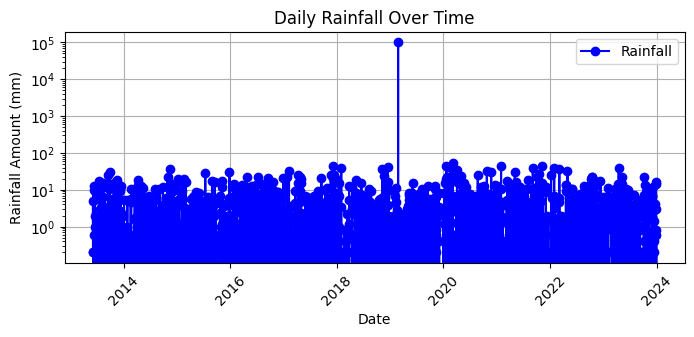

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(rain_df['date'], rain_df['Rainfall amount (millimetres)'], marker='o', linestyle='-', color='b', label='Rainfall')
plt.xlabel('Date')
plt.ylabel('Rainfall Amount (mm)')
plt.title('Daily Rainfall Over Time')
plt.yscale('log')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [87]:
# Remove rainfall < 0 or > 10000 outliers
outliers = rain_df[(rain_df['Rainfall amount (millimetres)'] < 0) | 
                  (rain_df['Rainfall amount (millimetres)'] > 10000)]
print(outliers)
rain_df = rain_df.drop(outliers.index).reset_index(drop=True)

      Year  Month  Day  Rainfall amount (millimetres)       date
2086  2019      2   24                       100000.0 2019-02-24
2151  2019      4   30                          -10.0 2019-04-30


In [88]:
# Drop the date column and export dataframe to csv file
rain_df = rain_df.drop(columns=['date'])
rain_df.to_csv('Data_clean.csv', index=False)

# Task 2: Data Exploration

## Task 2.1 
Prepare and convert the data in 2014 as a pandas DataFrame with rows as the days in a month and columns as the months in a year (e.g. row 1 contains the rainfall data in the 1st day of each month; row 2 contains the rainfall data in the 2nd day of each month, ...). Then, explore the highest daily rainfall in each month.


Month   1    2    3    4    5    6    7     8     9    10   11   12
Day                                                                
1      0.0  0.0  0.0  0.0  0.0  3.8  0.4   5.2   0.0  2.6  6.0  0.0
2      5.2  0.0  0.0  0.0  0.0  3.2  0.0  10.6  10.8  0.0  0.2  0.4
3      0.0  0.0  0.0  0.2  1.4  3.4  0.0   0.6   0.2  0.6  0.0  0.0
4      0.0  0.4  0.0  0.0  5.6  1.6  0.0   0.0   0.0  0.2  0.0  9.0
5      0.2  0.0  0.0  0.0  1.8  4.8  0.0   0.0   0.0  0.0  0.0  0.0


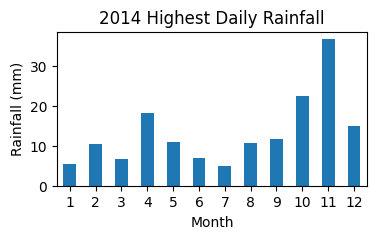

In [109]:
import pandas as pd

df = pd.read_csv('Data_clean.csv', sep=',', decimal='.', header=0)
rain_2014 = df[df['Year'] == 2014]
rain_pivot = rain_2014.pivot(index='Day', columns='Month', values='Rainfall amount (millimetres)').sort_index()
print(rain_pivot.head())

# Get the highest daily rainfall in each month
max_rainfall_per_month = rain_pivot.max(axis=0)
max_rainfall_per_month.plot(kind='bar',figsize=(4, 2))
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.title('2014 Highest Daily Rainfall')
plt.xticks(rotation=0)
plt.show()

## Task 2.2 
Explore the data between 2015 and 2017, and analyse them on both a yearly and monthly basis with visualizations.

Year
2015    439.2
2016    599.6
2017    602.0
Name: Rainfall amount (millimetres), dtype: float64


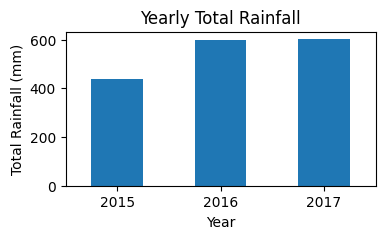

In [110]:
# Filter data for years 2015-2017 and get yearly total rainfall
rain_2015_2017 = df[(df['Year'] >= 2015) & (df['Year'] <= 2017)]
yearly_rainfall = rain_2015_2017.groupby('Year')['Rainfall amount (millimetres)'].sum()
print(yearly_rainfall)

yearly_rainfall.plot(kind='bar',figsize=(4, 2))
plt.xlabel('Year')
plt.ylabel('Total Rainfall (mm)')
plt.title('Yearly Total Rainfall')
plt.xticks(rotation=0)
plt.show()


   Year  Month  Rainfall amount (millimetres)
0  2015      1                           47.4
1  2015      2                           37.8
2  2015      3                           23.0
3  2015      4                           36.8
4  2015      5                           37.6


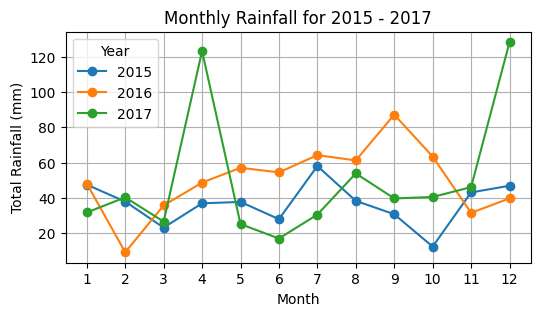

In [113]:
# Monthly total rainfall across year 2015-2017
monthly_rainfall = rain_2015_2017.groupby(['Year', 'Month'])['Rainfall amount (millimetres)'].sum().reset_index()
print(monthly_rainfall.head())
monthly_rainfall_pivot = monthly_rainfall.pivot(index='Month', columns='Year', values='Rainfall amount (millimetres)')

monthly_rainfall_pivot.plot(kind='line', marker='o', figsize=(6,3))
plt.xlabel('Month')
plt.ylabel('Total Rainfall (mm)')
plt.title('Monthly Rainfall for 2015 - 2017')
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.grid(True)
plt.show()

## Task 2.3 
Explore the data, and find the top 3 years with the highest rainfall amount and the top 3 years with the lowest rainfall amount, then compare them.

Year
2013    380.2
2014    432.0
2015    439.2
2016    599.6
2017    602.0
2018    514.4
2019    374.4
2020    786.8
2021    682.6
2022    699.4
2023    574.0
Name: Rainfall amount (millimetres), dtype: float64


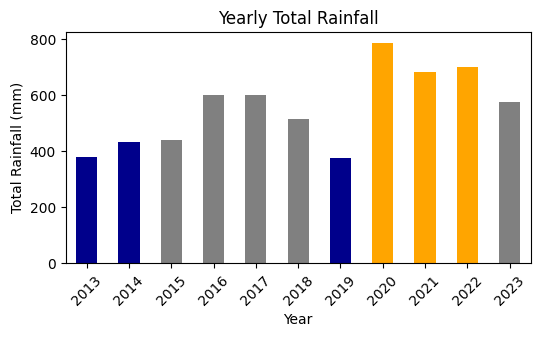

In [115]:
# Yearly total rainfall 
yearly_rainfall = df.groupby('Year')['Rainfall amount (millimetres)'].sum() 
print(yearly_rainfall)

# Sort the data to find the top 3 years with the highest and lowest rainfall
top_3_years = yearly_rainfall.sort_values(ascending=False).head(3)
low_3_years = yearly_rainfall.sort_values(ascending=True).head(3)

# Assign colors based on year ranking
colors = [
    'orange' if year in top_3_years.index else
    'darkblue' if year in low_3_years.index else
    'gray' 
    for year in yearly_rainfall.index
]

yearly_rainfall.plot(kind='bar', figsize=(6, 3), color=colors)
plt.xlabel('Year')
plt.ylabel('Total Rainfall (mm)')
plt.title('Yearly Total Rainfall')
plt.xticks(rotation=45)
plt.show()

> <span style="font-size:1em;">✔</span> **Observations:** 

The chart shows that the top three years with the highest rainfall amounts are 2020, 2021, and 2022. The three years with the lowest rainfall amounts are 2013, 2014, and 2019.

Year 2020 has the highest total rainfall: 786.8 mm
Year 2019 has the lowest total rainfall: 374.4 mm
The difference between the highest and lowest total rainfall years: 412.4 mm


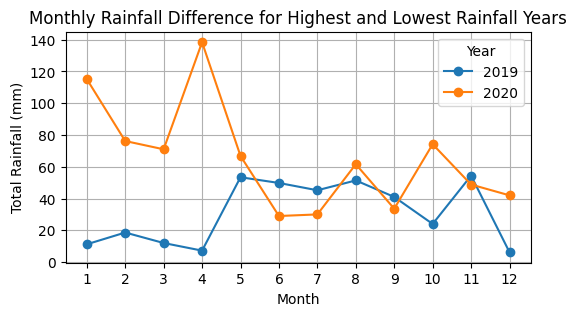

In [116]:
# Compare the highest and lowest total year raifall 
high_low_diff = top_3_years.iloc[0] - low_3_years.iloc[0]
print(f'Year {top_3_years.index[0]} has the highest total rainfall: {top_3_years.iloc[0]} mm')
print(f'Year {low_3_years.index[0]} has the lowest total rainfall: {low_3_years.iloc[0]} mm')
print(f'The difference between the highest and lowest total rainfall years: {high_low_diff} mm')

# Filter data for years 2019 & 2020
rain_2019_2020 = df[(df['Year'] == 2019) | (df['Year'] == 2020)]
monthly_rainfall = rain_2019_2020.groupby(['Year', 'Month'])['Rainfall amount (millimetres)'].sum().reset_index()
monthly_rainfall_pivot = monthly_rainfall.pivot(index='Month', columns='Year', values='Rainfall amount (millimetres)')

monthly_rainfall_pivot.plot(kind='line', marker='o', figsize=(6,3))
plt.xlabel('Month')
plt.ylabel('Total Rainfall (mm)')
plt.title('Monthly Rainfall Difference for Highest and Lowest Rainfall Years')
plt.xticks(range(1, 13)) 
plt.legend(title="Year")
plt.grid(True) 
plt.show()


> <span style="font-size:1em;">✔</span> **Observations:** 

The chart shows that 2020 experienced significantly higher rainfall than 2019, especially in the early months of the year, with a clear peak in April. The difference between the two years narrows in the middle months, where rainfall levels become more similar and occasionally higher in 2019. Overall, 2020 stands out as a much wetter year, while 2019 remains comparatively drier and more consistent.

## Task 2.4 
Explore the changes of rainfall in ABC City in the last 10 years.

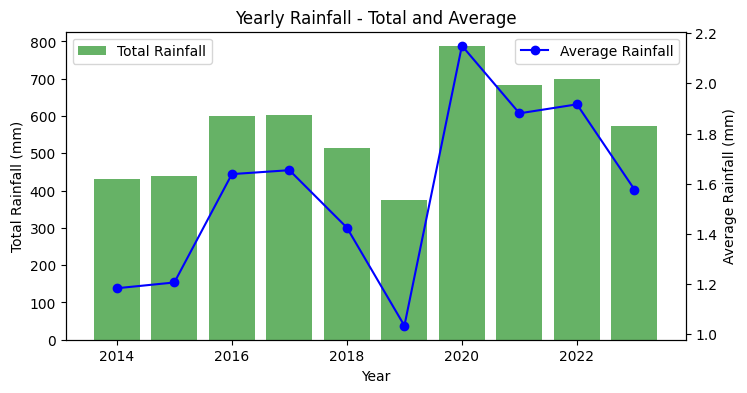

In [121]:
rain_10_years = df[(df['Year'] >= 2014) & (df['Year'] <= 2023)]
# Get total rainfall of each year
yearly_rainfall = rain_10_years.groupby('Year')['Rainfall amount (millimetres)'].sum()  
# Get average rainfall of each year
yearly_avg_rainfall = rain_10_years.groupby('Year')['Rainfall amount (millimetres)'].mean() 

# Plot setup with two y-axes
fig, ax1 = plt.subplots(figsize=(8, 4))
# Plot the total rainfall (left y-axis) as a bar chart
ax1.bar(yearly_rainfall.index, yearly_rainfall.values, color='green', alpha=0.6, label='Total Rainfall')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Rainfall (mm)')
ax1.tick_params(axis='y')
ax1.set_title('Yearly Rainfall - Total and Average')

# Create a second y-axis for the average rainfall (right y-axis)
ax2 = ax1.twinx()  
# Plot the average rainfall as a line with markers
ax2.plot(yearly_avg_rainfall.index, yearly_avg_rainfall.values, color='blue', marker='o', label='Average Rainfall', linestyle='-', markersize=6)
ax2.set_ylabel('Average Rainfall (mm)')
ax2.tick_params(axis='y')

# Add legends for both axes
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.xticks(rotation=90)
plt.show()

> <span style="font-size:1em;">✔</span> **Observations:** 

The chart shows that rainfall fluctuates over the years, with a general increase from 2014 to 2017, followed by a decline in 2018 and a sharp drop in 2019, the driest year. Rainfall then rises significantly to a peak in 2020, the wettest year, before decreasing slightly but remaining relatively high in 2021 and 2022. Overall, total and average rainfall follow a similar trend throughout the period.

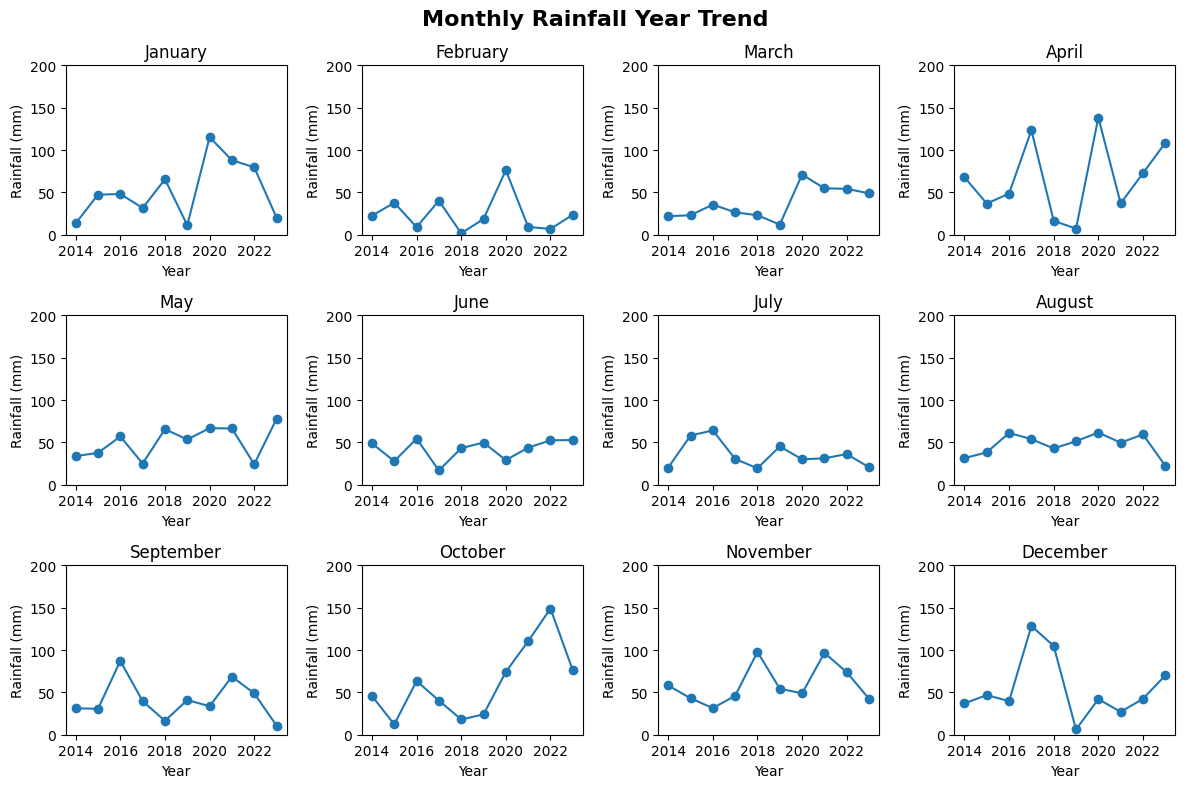

In [136]:
import calendar

monthly_rainfall = rain_10_years.groupby(['Year', 'Month'])['Rainfall amount (millimetres)'].sum().unstack()

# Get the months from the column names
months = monthly_rainfall.columns

plt.figure(figsize=(12, 8))
plt.suptitle("Monthly Rainfall Year Trend", fontsize=16, fontweight='bold')

# Loop through each month and plot it
for index, month in enumerate(months):
    plt.subplot(3, 4, index + 1)
    plt.plot(monthly_rainfall.index, monthly_rainfall[month], marker='o') 
    # plt.title(f'Month {month}')
    plt.title(f'{calendar.month_name[month]}')
    plt.xlabel('Year')
    plt.ylabel('Rainfall (mm)')
    plt.ylim(0, 200)

plt.tight_layout()
plt.show()

> <span style="font-size:1em;">✔</span> **Observations:** 

The charts show that April, October, and December are the wettest months and have the biggest jumps in rainfall from year to year. On the other hand, June, July, and August stay much drier and steady, almost always staying below 60 mm. There was a big spike in early 2020 where it rained a lot more than usual, but by 2023, the amount of rain dropped significantly for almost every month.